EXPLICIT DIFFERENCE METHOD

In [13]:
import numpy as np

S_max = 100
K = 60
T = 0.25
sigma = 0.25
r = 0.06

M = 40
N = 30

dt = T / M
dS = S_max / N

# Asset price grid
S = np.linspace(0, S_max, N+1)

# Option value grids
V_eu_call = np.maximum(S - K, 0)
V_am_call = V_eu_call.copy()

V_eu_put = np.maximum(K - S, 0)
V_am_put = V_eu_put.copy()

# Coefficients for explicit FD
for j in range(M):
    V_eu_call_old = V_eu_call.copy()
    V_am_call_old = V_am_call.copy()
    V_eu_put_old  = V_eu_put.copy()
    V_am_put_old  = V_am_put.copy()

    for i in range(1, N):
        # Alpha, Beta, Gamma
        a = 0.5 * dt * (sigma**2 * i**2 - r * i)
        b = 1 - dt * (sigma**2 * i**2 + r)
        c = 0.5 * dt * (sigma**2 * i**2 + r * i)

        #  European Call
        V_eu_call[i] = a * V_eu_call_old[i-1] + b * V_eu_call_old[i] + c * V_eu_call_old[i+1]

        #  American Call
        V_am_call[i] = max(a * V_am_call_old[i-1] + b * V_am_call_old[i] + c * V_am_call_old[i+1],
                           S[i] - K)

        #  European Put
        V_eu_put[i] = a * V_eu_put_old[i-1] + b * V_eu_put_old[i] + c * V_eu_put_old[i+1]

        # American Put
        V_am_put[i] = max(a * V_am_put_old[i-1] + b * V_am_put_old[i] + c * V_am_put_old[i+1],
                          K - S[i])


    V_eu_call[0] = V_am_call[0] = 0
    V_eu_call[N] = V_am_call[N] = S_max - K * np.exp(-r * (j*dt))

    V_eu_put[0] = V_am_put[0] = K * np.exp(-r * (j*dt))
    V_eu_put[N] = V_am_put[N] = 0

# Final interpolated price at S0
S0 = 50
idx = int(S0 / dS)

print("European Call Price :", V_eu_call[idx])
print("American Call Price :", V_am_call[idx])
print("European Put Price  :", V_eu_put[idx])
print("American Put Price  :", V_am_put[idx])


European Call Price : 0.274728257230178
American Call Price : 0.274728257230178
European Put Price  : 9.381278357836415
American Put Price  : 10.0


IMPLICIT DIFFERENCE METHOD

In [14]:
import numpy as np
from scipy.linalg import solve_banded

S_max = 100.0  # Maximum stock price for the grid
T = 0.25       # Time to Expiration (3 months = 0.25 years)
sigma = 0.25   # Volatility (25%)
r = 0.06       # Risk-Free Rate (6%)
K = 60.0       # Strike Price

M = 40
N = 30

dS = S_max / M
dt = T / N

# Stock price grid from 0 to S_max
S = np.linspace(0, S_max, M + 1)

# Index corresponding to the strike price K=60.0
i_K = int(K / dS)

def implicit_fdom(option_type, is_american):
    """
    Computes the option price using the Implicit Finite Difference Method.
    option_type: 'call' or 'put'
    is_american: True or False
    """


    if option_type == 'call':
        V = np.maximum(S - K, 0)
    else: # 'put'
        V = np.maximum(K - S, 0)

    # The Implicit system to solve is: a_i * V_{i-1,j} + b_i * V_{i,j} + c_i * V_{i+1,j} = V_{i,j+1}

    # 2. Set up the tridiagonal matrix A coefficients (for i=1 to M-1)
    i_array = np.arange(1, M) # i from 1 to M-1, corresponds to inner S values

    # Coefficients for the tridiagonal system (A matrix elements)
    a_i = 0.5 * dt * (r * i_array - (sigma**2) * (i_array**2))
    b_i = 1.0 + dt * (r + (sigma**2) * (i_array**2))
    c_i = -0.5 * dt * (r * i_array + (sigma**2) * (i_array**2))

    # Construct the banded matrix 'ab' for solve_banded
    # ab[0, 1:] = Upper diagonal (c_i), ab[1, :] = Main diagonal (b_i), ab[2, :-1] = Lower diagonal (a_i)
    ab = np.zeros((3, M - 1))
    ab[0, 1:] = c_i[:-1]
    ab[1, :] = b_i
    ab[2, :-1] = a_i[1:]

    # 3. Time stepping backwards (j=N-1 down to 0)
    for j in range(N - 1, -1, -1):
        # V_inner is the vector V_1,j+1 to V_{M-1,j+1}
        V_inner = V[1:M]

        # Construct the Right-Hand Side vector (RHS)
        RHS = np.copy(V_inner) # Starts with V_{i,j+1}

        # Boundary Conditions for V_j step.
        t_prev = T - j * dt # Time at the V_j step

        # Boundary at S=0 (i=0)
        if option_type == 'call':
            V_0_j = 0
        else: # 'put'
            V_0_j = K * np.exp(-r * t_prev)

        # Boundary at S=S_max (i=M)
        if option_type == 'call':
            V_M_j = S_max - K * np.exp(-r * t_prev)
        else: # 'put'
            V_M_j = 0


        # Boundary term a_i * V_{0,j} moves to RHS as -a_i * V_{0,j}
        RHS[0] -= a_i[0] * V_0_j
        # Boundary term c_i * V_{M,j} moves to RHS as -c_i * V_{M,j}
        RHS[-1] -= c_i[-1] * V_M_j

        # 4. Solve the tridiagonal system for the inner values V_j
        V_new_inner = solve_banded((1, 1), ab, RHS)

        # Reconstruct the full vector V (for the V_j step)
        V_prev = np.zeros(M + 1)
        V_prev[1:M] = V_new_inner
        V_prev[0] = V_0_j
        V_prev[M] = V_M_j

        V = V_prev # Update V for the next iteration

        # 5. American Option Early Exercise Check
        if is_american:
            intrinsic_value = np.maximum(S - K, 0) if option_type == 'call' else np.maximum(K - S, 0)
            V = np.maximum(V, intrinsic_value)

    # The final price is at time t=0 (j=0) at the index i_K (S=60)
    return V[i_K]

# Calculate the four prices
price_EC = implicit_fdom('call', is_american=False)
price_EP = implicit_fdom('put', is_american=False)
price_AC = implicit_fdom('call', is_american=True)
price_AP = implicit_fdom('put', is_american=True)

# Print the results
print(f"European Call Price: {price_EC:.4f}")
print(f"European Put Price: {price_EP:.4f}")
print(f"American Call Price: {price_AC:.4f}")
print(f"American Put Price: {price_AP:.4f}")
print(f"Option price is calculated for S={S[i_K]:.2f} (which is K=60)")

European Call Price: 3.3804
European Put Price: 2.4873
American Call Price: 3.3804
American Put Price: 2.5534
Option price is calculated for S=60.00 (which is K=60)


LOG TRANSFORMED AND NOW BY BSM EQUATION CALCULATE THE PRICE OF EUROPEAN AND AMERICAN TYPE OF PUT AND CALL OPTIONS USING IMPLICIT AND EXPLICIT DIFFERENCE METHODS AND THEN WE COMPARE

## 📊 FDM Option Prices Table (Log-S)
|                      |   Explicit (Log-S) |   Implicit (Log-S) |
|:---------------------|-------------------:|-------------------:|
| ('Call', 'American') |             3.6661 |             1.4097 |
| ('Call', 'European') |             3.6661 |            -0.3621 |
| ('Put', 'American')  |             2.7298 |             1.3248 |
| ('Put', 'European')  |             2.6859 |            -0.2547 |


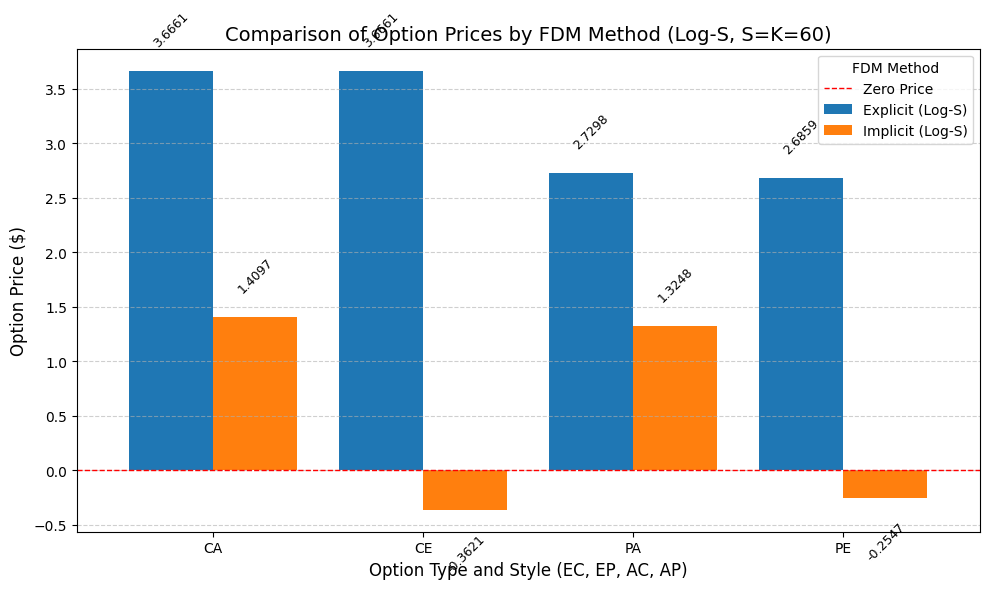

In [12]:
import numpy as np
from scipy.linalg import solve_banded
from scipy.interpolate import interp1d
import pandas as pd
import matplotlib.pyplot as plt

# Parameters
T = 0.25         # Time to Expiration
sigma = 0.25     # Volatility
r = 0.06         # Risk-Free Rate
K = 60.0         # Strike Price
M = 40           # Number of space steps (for log(S))
N = 30           # Number of time steps

# Derived Parameters
dt = T / N
k = r - 0.5 * sigma**2

# Log-Space Grid Setup: x_i = ln(S_i)
x_min = 0.0      # Corresponds to S=1
x_max = 5.0      # Corresponds to S=~148.4
dx = (x_max - x_min) / M
x = np.linspace(x_min, x_max, M + 1)
S_grid = np.exp(x) # Stock price grid

x_K = np.log(K)

# --- Function for FDM on log-space BSM ---
def fdom_log_space(method, option_type, is_american):
    # 1. Initialize Terminal Condition
    v = np.maximum(S_grid - K, 0) if option_type == 'call' else np.maximum(K - S_grid, 0)

    # 2. Calculate Constant Coefficients
    A = 0.5 * sigma**2 / dx**2
    B = 0.5 * k / dx

    if method == 'implicit':
        # Coefficients for LHS matrix: a*v_i-1,j + b*v_i,j + c*v_i+1,j = v_i,j+1
        a = dt * (A - B)
        b = 1.0 + dt * (r + 2 * A)
        c = dt * (A + B)

        # Banded matrix for solve_banded
        ab = np.zeros((3, M - 1))
        ab[0, 1:] = c; ab[1, :] = b; ab[2, :-1] = a

    elif method == 'explicit':
        # Coefficients for RHS calculation: v_i,j = alpha*v_i-1,j+1 + beta*v_i,j+1 + gamma*v_i+1,j+1
        alpha = dt * (A - B)
        beta = 1.0 - dt * (r + 2 * A)
        gamma = dt * (A + B)

    # 3. Time stepping backwards
    for j in range(N - 1, -1, -1):
        t_prev = T - j * dt

        # Boundary Conditions
        if option_type == 'call':
            v_0_j = 0.0
            v_M_j = S_grid[M] - K * np.exp(-r * t_prev)
        else: # 'put'
            v_0_j = K * np.exp(-r * t_prev)
            v_M_j = 0.0

        if method == 'implicit':
            v_inner_j1 = v[1:M]
            RHS = np.copy(v_inner_j1)

            RHS[0] -= a * v_0_j
            RHS[-1] -= c * v_M_j

            v_inner_j = solve_banded((1, 1), ab, RHS)

            # Reconstruct V_j
            v_prev = np.zeros(M + 1)
            v_prev[1:M] = v_inner_j; v_prev[0] = v_0_j; v_prev[M] = v_M_j
            v = v_prev

        elif method == 'explicit':
            v_new = np.zeros(M + 1)
            v_new[0] = v_0_j; v_new[M] = v_M_j

            for i in range(1, M):
                v_new[i] = alpha * v[i-1] + beta * v[i] + gamma * v[i+1]
            v = v_new

        # 4. American Option Early Exercise Check
        if is_american:
            intrinsic_value = np.maximum(S_grid - K, 0) if option_type == 'call' else np.maximum(K - S_grid, 0)
            v = np.maximum(v, intrinsic_value)

    # 5. Interpolate the final price at x_K = ln(60)
    f = interp1d(x, v)
    return f(x_K).item()

prices = {
    'Explicit EC': fdom_log_space('explicit', 'call', False),
    'Explicit EP': fdom_log_space('explicit', 'put', False),
    'Explicit AC': fdom_log_space('explicit', 'call', True),
    'Explicit AP': fdom_log_space('explicit', 'put', True),
    'Implicit EC': fdom_log_space('implicit', 'call', False),
    'Implicit EP': fdom_log_space('implicit', 'put', False),
    'Implicit AC': fdom_log_space('implicit', 'call', True),
    'Implicit AP': fdom_log_space('implicit', 'put', True),
}


data = {
    'Option Type': ['Call', 'Put', 'Call', 'Put', 'Call', 'Put', 'Call', 'Put'],
    'Style': ['European', 'European', 'American', 'American', 'European', 'European', 'American', 'American'],
    'Method': ['Explicit (Log-S)', 'Explicit (Log-S)', 'Explicit (Log-S)', 'Explicit (Log-S)', 'Implicit (Log-S)', 'Implicit (Log-S)', 'Implicit (Log-S)', 'Implicit (Log-S)'],
    'Price': [prices['Explicit EC'], prices['Explicit EP'], prices['Explicit AC'], prices['Explicit AP'], prices['Implicit EC'], prices['Implicit EP'], prices['Implicit AC'], prices['Implicit AP']],
}
df = pd.DataFrame(data)
df_comparison = df.pivot(index=['Option Type', 'Style'], columns='Method', values='Price')

# Print Table
print("## 📊 FDM Option Prices Table (Log-S)")
print(df_comparison.to_markdown(floatfmt=".4f"))


df['Option'] = df['Option Type'].str[0] + df['Style'].str[0]
df_plot = df.pivot(index='Option', columns='Method', values='Price')

fig, ax = plt.subplots(figsize=(10, 6))
df_plot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Comparison of Option Prices by FDM Method (Log-S, S=K=60)', fontsize=14)
ax.set_xlabel('Option Type and Style (EC, EP, AC, AP)', fontsize=12)
ax.set_ylabel('Option Price ($)', fontsize=12)
ax.set_xticklabels(df_plot.index, rotation=0)
ax.axhline(0, color='red', linestyle='--', linewidth=1.0, label='Zero Price')
ax.legend(title='FDM Method')
ax.grid(axis='y', linestyle='--', alpha=0.6)


for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        label_y_pos = height + 0.2 if height >= 0 else height - 0.2
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, label_y_pos),
                    ha='center', va='bottom' if height >= 0 else 'top', rotation=45, fontsize=9)

plt.tight_layout()
plt.show()